## 실습 4: 센서 하나로 이상 구간 찾기
- 상황: 3라인 계측 기록에서 평소와 다르게 튄 구간을 찾아본다
- 목표: 관리선을 긋고 벗어난 구간을 잡는다

In [1]:
import pandas as pd

df = pd.read_csv("../../data/04_secom.csv")

# 1. 전체 크기 — (행 개수, 열 개수)
print("행/열:", df.shape)

# 2. result 열 — 값 종류별 건수, 그리고 비율
print("\n[건수]")
print(df["result"].value_counts())
print("\n[비율]")
print(df["result"].value_counts(normalize=True))

# 3. 앞부분 보기 — 열이 많으면 가운데가 ...으로 잘린다
df.head()

행/열: (1567, 592)

[건수]
result
양품    1463
불량     104
Name: count, dtype: int64

[비율]
result
양품    0.933631
불량    0.066369
Name: proportion, dtype: float64


,measured_at,sensor_001,sensor_002,sensor_003,sensor_004,sensor_005,sensor_006,sensor_007,sensor_008,sensor_009,...,sensor_582,sensor_583,sensor_584,sensor_585,sensor_586,sensor_587,sensor_588,sensor_589,sensor_590,result
0,19/07/2008 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,양품
1,19/07/2008 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,양품
2,19/07/2008 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,불량
3,19/07/2008 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,양품
4,19/07/2008 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,양품


### 용어 풀이 - 관리도 주변

| 말 | 뜻 |
|---|---|
| 관리도 | 값을 시간 순서대로 그려두고, 평소 범위를 벗어나는 순간을 잡는 그림 |
| 관리선 | 평소 범위의 경계선. 위쪽 선을 관리 상한, 아래쪽 선을 관리 하한이라 부른다 |
| 평균 | 값들을 다 더해 개수로 나눈 것. 관리도의 한가운데 선이 된다 |
| 표준편차 | 값들이 평균에서 얼마나 흩어져 있는지. 작으면 몰려 있고 크면 넓게 퍼져 있다 |
| 이상 구간 | 관리선을 벗어난 구간. 벗어났다는 것이지 곧 불량이라는 뜻은 아니다 |
| result (판정) | 검사에서 붙은 양품 또는 불량. 공정이 다 끝난 뒤에 붙는다 |
| SPC | 이런 방식으로 공정을 감시하는 것을 통틀어 부르는 말 |

In [2]:
# 쓸 만한 센서 열 5개를 골라 한 표로 정리한다

sensors = df.filter(like="sensor_")

# 조건 1: isna().sum() == 0 — 빈칸이 하나도 없다
# 조건 2: nunique() > 1 — 값 종류가 2가지 이상이다 (항상 같은 값이면 볼 게 없다)
usable = [c for c in sensors.columns
          if sensors[c].isna().sum() == 0 and sensors[c].nunique() > 1]
picked = usable[:5]          # 앞에서 5개만

rows = []
for c in picked:
    s = df[c]
    kinds = s.nunique()      # 서로 다른 값이 몇 가지인지
    lo, hi = s.min(), s.max()

    # 판정은 오직 '값 종류 수'로만 한다. 값의 범위가 좁은지 넓은지는 보지 않는다
    # 열 가지 안쪽 → 몇 단계로 정해 넣은 값 / 수십 가지 이상 → 계속 재서 기록한 값
    nature = "정해 넣은 값에 가까움" if kinds <= 10 else "재고 있는 값에 가까움"

    # 최대값의 자릿수만 보고 성격을 짐작한다 (짐작일 뿐이다)
    if hi < 1:
        guess = "1 미만 — 비율이나 아주 미세한 값?"
    elif hi < 100:
        guess = "한두 자리 — 작은 눈금의 값?"
    else:
        guess = "세 자리 이상 — 큰 수로 세는 값?"

    rows.append({
        "센서": c,
        "범위": f"{lo} ~ {hi}",
        "값 종류 수": kinds,
        "값의 성격": nature,
        "자릿수로 본 짐작": guess,
    })

summary = pd.DataFrame(rows).set_index("센서")

print("조건을 만족하는 열:", len(usable), "개 중 앞에서 5개")
print("판정 기준: 값 종류 수 10가지 이하 → 정해 넣은 값 / 그보다 많으면 → 재고 있는 값")
print("⚠️ '자릿수로 본 짐작' 칸은 계산 결과가 아니라 자릿수만 보고 붙인 이름표다.")
print("⚠️ 열 이름이 sensor_021처럼 번호뿐이라, 실제로 무엇을 재는 센서인지는 알 수 없다.")
summary

조건을 만족하는 열: 52 개 중 앞에서 5개
판정 기준: 값 종류 수 10가지 이하 → 정해 넣은 값 / 그보다 많으면 → 재고 있는 값
⚠️ '자릿수로 본 짐작' 칸은 계산 결과가 아니라 자릿수만 보고 붙인 이름표다.
⚠️ 열 이름이 sensor_021처럼 번호뿐이라, 실제로 무엇을 재는 센서인지는 알 수 없다.


,범위,값 종류 수,값의 성격,자릿수로 본 짐작
센서,,,,
sensor_021,1.1797 ~ 1.4534,552,재고 있는 값에 가까움,한두 자리 — 작은 눈금의 값?
sensor_087,2.2425 ~ 2.5555,472,재고 있는 값에 가까움,한두 자리 — 작은 눈금의 값?
sensor_088,0.7749 ~ 0.9935,249,재고 있는 값에 가까움,1 미만 — 비율이나 아주 미세한 값?
sensor_089,1627.4714 ~ 2105.1823,973,재고 있는 값에 가까움,세 자리 이상 — 큰 수로 세는 값?
sensor_114,0.8534 ~ 0.9763,468,재고 있는 값에 가까움,1 미만 — 비율이나 아주 미세한 값?


[내가 고른 열]<br>
고른 열 : [sensor_089]<br>
값 범위 : [1627.47] ~ [2105.18]   값 종류 : [973]가지<br>
값 종류가 [많으니] 이 열은 [재고 있는 값]에 가깝다<br>
AI가 본 성격 : [세 자리 이상 — 큰 수로 세는 값]

## Step 4. 평소 범위를 정하기
평균에서 표준편차 3배만큼 위아래로 관리선을 긋는다.

In [3]:
# 앞에서 고른 센서 이름을 넣는다 (본인이 고른 것으로 바꾸세요)
센서 = "sensor_089"

# 평균 — 이 센서 값들의 한가운데
평균 = df[센서].mean()

# 표준편차 — 값들이 평균에서 얼마나 흩어져 있는지
표준편차 = df[센서].std()

# 관리 상한 / 하한 — 평균에서 표준편차 3배만큼 위아래
위선 = 평균 + 3 * 표준편차
아래선 = 평균 - 3 * 표준편차

# round(값, 2) — 소수점 둘째 자리까지만 보여준다
print("평균:", round(평균, 2))
print("관리 상한:", round(위선, 2))
print("관리 하한:", round(아래선, 2))

평균: 1807.82
관리 상한: 1968.43
관리 하한: 1647.2


## Step 5. 관리도 그리기

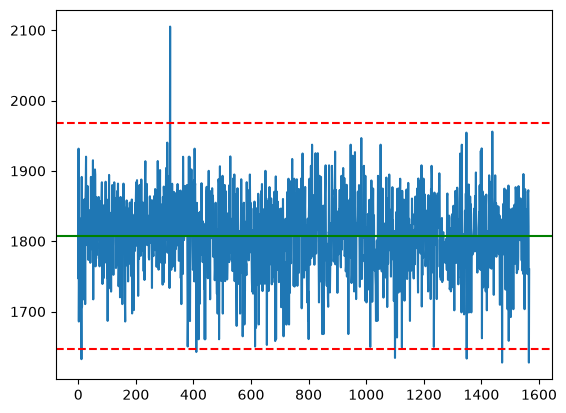

In [4]:
# 그림 그리는 도구를 plt라는 짧은 이름으로 불러온다
import matplotlib.pyplot as plt

# 센서 값을 측정 순서대로 선으로 그린다
plt.plot(df[센서])

# axhline — 가로로 쭉 뻗는 선 하나를 긋는다 (h는 horizontal, 수평)
# color는 색, linestyle="--"는 점선
plt.axhline(평균, color="green")
plt.axhline(위선, color="red", linestyle="--")
plt.axhline(아래선, color="red", linestyle="--")

# 그림을 화면에 띄운다
plt.show()

### 문법 노트 - 그림 그리기 첫걸음

| 쓴 것 | 하는 일 |
|---|---|
| plt.plot(값들) | 값을 순서대로 이어 선으로 그린다 |
| plt.axhline(높이) | 그 높이에 가로선 하나를 긋는다. 관리선이 바로 이것 |
| color="red" | 선 색을 정한다 |
| linestyle="--" | 선을 점선으로 만든다 (실선인 평균선과 구분되게) |
| plt.show() | 지금까지 얹은 것들을 한 장으로 띄운다 |
| round(값, 2) | 소수점 둘째 자리까지만 남긴다 |

**한 장의 도화지에 하나씩 얹는 방식이다.**<br>
선을 그리고, 그 위에 가로선을 세 개 얹고, 마지막에 show로 완성해서 보여준다.<br>
그래서 순서대로 쭉 쓰면 된다.

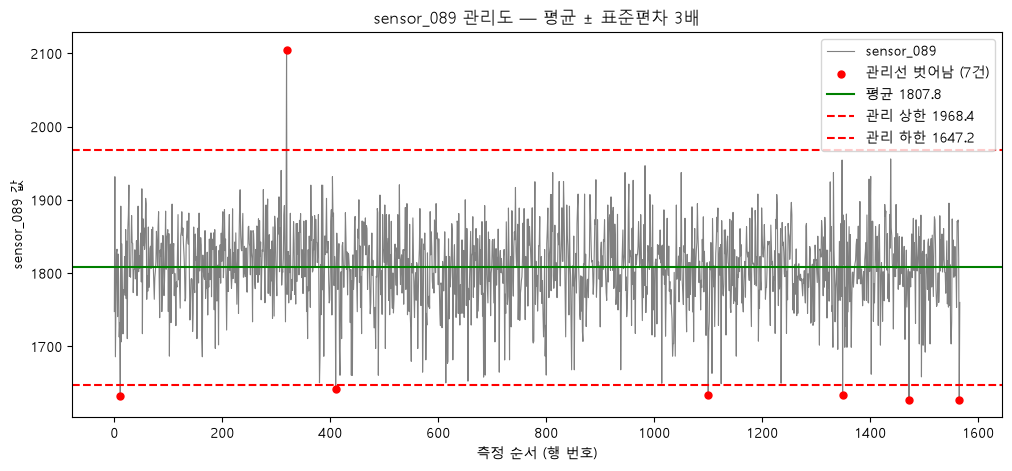

저장함: results\sensor_089_관리도.png


In [5]:
# 관리도 다듬기 — 벗어난 점 표시, 이름표, 제목과 축 이름, 파일로 저장
from pathlib import Path

# 한글이 네모(□)로 깨지지 않게 글꼴을 지정한다 (윈도우 기본 한글 글꼴)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False   # 마이너스 기호가 깨지는 것 방지

값 = df[센서]

# 관리선을 벗어난 점 — 위선보다 크거나(|) 아래선보다 작은 것
벗어남 = (값 > 위선) | (값 < 아래선)

# figsize=(가로, 세로) — 도화지 크기를 키운다. 점이 1567개라 넓어야 보인다
plt.figure(figsize=(12, 5))

# 전체 값은 옅은 회색 선으로
plt.plot(값.index, 값, color="gray", linewidth=0.8, label=센서)

# 벗어난 점만 빨간 점으로 덧그린다
# scatter — 선이 아니라 점만 찍는다. zorder=3은 선보다 위에 그리라는 뜻
plt.scatter(값.index[벗어남], 값[벗어남],
            color="red", s=25, zorder=3,
            label=f"관리선 벗어남 ({벗어남.sum()}건)")

# label= 을 붙여두면 legend()가 그 이름표를 모아서 상자로 보여준다
plt.axhline(평균, color="green", label=f"평균 {평균:.1f}")
plt.axhline(위선, color="red", linestyle="--", label=f"관리 상한 {위선:.1f}")
plt.axhline(아래선, color="red", linestyle="--", label=f"관리 하한 {아래선:.1f}")

plt.title(f"{센서} 관리도 — 평균 ± 표준편차 3배")
plt.xlabel("측정 순서 (행 번호)")
plt.ylabel(f"{센서} 값")
plt.legend()          # 이름표 상자를 띄운다

# 이 노트북 폴더 안에 results 폴더를 만들고 그림을 저장한다
저장폴더 = Path("results")
저장폴더.mkdir(exist_ok=True)          # 이미 있으면 그냥 넘어간다
저장경로 = 저장폴더 / f"{센서}_관리도.png"

# savefig는 show보다 먼저 해야 한다. show 뒤에는 도화지가 비워져서 빈 그림이 저장된다
# bbox_inches="tight" — 그림 둘레의 빈 여백을 잘라낸다
plt.savefig(저장경로, dpi=150, bbox_inches="tight")

plt.show()
print("저장함:", 저장경로)

선을 넘은 점 : 대략 [7]개<br>
몰려 있나 흩어져 있나 : [앞쪽에 세 개가 붙어 있고 나머지는 뒤쪽에 흔어져 있다]

## Step 6. 선을 넘은 것이 불량이었나

In [6]:
# 관리선을 벗어난 행만 골라, 그 행들의 판정(result)을 세어 전체와 비교한다

벗어난행 = df[벗어남]          # 벗어남은 앞 칸에서 만든 참/거짓 표시
print("벗어난 행 수:", len(벗어난행), "/ 전체:", len(df))

# 어떤 행이었는지 직접 본다
print("\n[벗어난 행]")
print(벗어난행[[센서, "result"]])

# 벗어난 행의 판정별 건수 / 전체의 판정별 건수
비교 = pd.DataFrame({
    "벗어난 행": 벗어난행["result"].value_counts(),
    "전체": df["result"].value_counts(),
})
비교 = 비교.fillna(0).astype(int)      # 한쪽에만 있는 판정은 0으로 채운다

# 각각을 비율(%)로도 계산한다
비교["벗어난 행 비율(%)"] = (비교["벗어난 행"] / len(벗어난행) * 100).round(1)
비교["전체 비율(%)"] = (비교["전체"] / len(df) * 100).round(1)

print("\n⚠️ 벗어난 행이", len(벗어난행), "건뿐이라 비율이 크게 흔들린다. 한 건 차이로 비율이 확 바뀐다.")
비교

벗어난 행 수: 7 / 전체: 1567

[벗어난 행]
      sensor_089 result
11     1632.3120     불량
319    2105.1823     양품
410    1642.5266     양품
1100   1634.0957     양품
1349   1633.1937     양품
1472   1627.4714     양품
1565   1627.4714     양품

⚠️ 벗어난 행이 7 건뿐이라 비율이 크게 흔들린다. 한 건 차이로 비율이 확 바뀐다.


,벗어난 행,전체,벗어난 행 비율(%),전체 비율(%)
result,,,,
양품,6,1463,85.7,93.4
불량,1,104,14.3,6.6


이 열이 무엇을 재는 값인지 - 이 데이터로 확인이 되나? : [안 된다]<br>
확인하려면 무엇이 더 있어야 하나? : [센서 번호와 실제 계측 항목을 이어주는 목록.<br>
공정 문서나 그 라인 담당자에게 물어봐야 한다]

## Step 7. 그런데 590개는요?

센서 1개를 확인하는 데 실행한 코드 칸과 AI 요청 : [5]번<br>
590개를 다 하려면? -> 590 x [5] = [2950]번<br>
게다가 그림 590장을 하나씩 눈으로 봐야 한다.

---
## 직접 해보기 (도전) - 선을 좁히면 어떻게 될까

- 상황: 관리선을 표준편차 3배로 그었다. 이건 관행일 뿐 정답이 아니다
- 할 일: 같은 센서에 2배로 다시 그어 3배일 때와 비교한다
- 결과물: 비교표 1개 + 어느 쪽이 나은지 내 판단 한 줄

In [7]:
# 관리선을 3배와 2배로 각각 그어 비교한다

전체불량비율 = (df["result"] == "불량").mean() * 100

기준표 = []
for 이름, 배수 in [("A (3배)", 3), ("B (2배)", 2)]:
    위 = 평균 + 배수 * 표준편차
    아래 = 평균 - 배수 * 표준편차

    넘음 = (df[센서] > 위) | (df[센서] < 아래)
    넘은행 = df[넘음]

    불량수 = (넘은행["result"] == "불량").sum()
    # 벗어난 행이 하나도 없으면 나눗셈이 안 되므로 갈라놓는다
    불량비율 = 불량수 / len(넘은행) * 100 if len(넘은행) > 0 else float("nan")

    기준표.append({
        "기준": 이름,
        "관리 하한": round(아래, 2),
        "관리 상한": round(위, 2),
        "벗어난 행": len(넘은행),
        "그중 불량": int(불량수),
        "불량 비율(%)": round(불량비율, 1),
        "전체(6.6%) 대비": f"{불량비율 / 전체불량비율:.1f}배",
    })

비교2 = pd.DataFrame(기준표).set_index("기준")

print("전체 불량 비율:", round(전체불량비율, 1), "%")
print("⚠️ 두 기준 모두 벗어난 행이 얼마 안 된다. 불량 몇 건 차이로 비율이 크게 흔들린다.")
비교2

전체 불량 비율: 6.6 %
⚠️ 두 기준 모두 벗어난 행이 얼마 안 된다. 불량 몇 건 차이로 비율이 크게 흔들린다.


,관리 하한,관리 상한,벗어난 행,그중 불량,불량 비율(%),전체(6.6%) 대비
기준,,,,,,
A (3배),1647.20,1968.43,7,1,14.3,2.2배
B (2배),1700.74,1914.89,81,5,6.2,0.9배


[관리선 2배 vs 3배]<br>
2배로 좁혔더니 벗어난 행이 [7]건에서 [81]건으로 늘었다.<br>
그중 불량 비율은 [14.3]%에서 [6.2]%로 [내렸다].<br>
내 선택 : [3배] - 이유 한 줄 : [많이 잡히는 것보다, 잡힌 것 중에 진짜가 많은 쪽이<br>
확인하러 갈 때 헛걸음이 적다고 봤다]